---
# **TRANSFERENCIA DE CIRCUITO ELÉCTRICO**

Obtención de las impedancias de cada componente y agrupando.

In [ ]:
from electro.circuits import symbolic as sym
from electro.circuits import parallel

# Declarar la variable simbólica s
ZC1 = sym.Z_capacitor(2)
ZC2 = sym.Z_capacitor()
ZL = sym.Z_inductor(1/2)

ZB = parallel([ZC2, 1])
VO = ZB/(ZB+ZC1+ZL)

sym.print_latex(VO)

---
# **GRÁFICO DE BODE Y POLOS Y CEROS**

Mediante la transferencia simbólica y el pasaje de coeficientes.

In [ ]:
from electro.graphics import plot
from electro.circuits.symbolic import s
from electro.circuits import symbolic as sym
from scipy.signal import tf2zpk

import numpy as np

# Impresión de bode utilizando Función simbolica
H = (s**2 + 1) / (s**2+2*s + 3)

num, den = sym.to_numeric_coeffs(H)
f = np.arange(0, 10e3, 10)

z, p, k = tf2zpk(num, den)
plot.plot_mag(num/den)

plot.pzmap(z, p)

# Impresión de bode utilizando Función numérica de coeficientes
num = [0, 0, 0, 1]  # Coeficientes del numerador
den = [1, 2, 2, 1]  # Coeficientes del denominador


---
# **UTILIZACIÓN DE FFT**

Ejemplo utilizando la fft para un análisis de muestras.
Se aplica una ventana y se obtiene la FFT de una señal senoidal + continua (teóricamente muestreada).

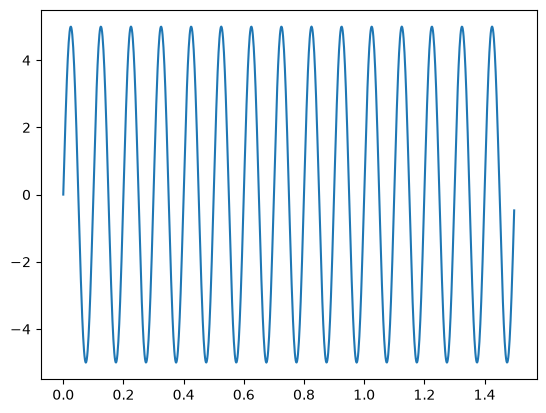

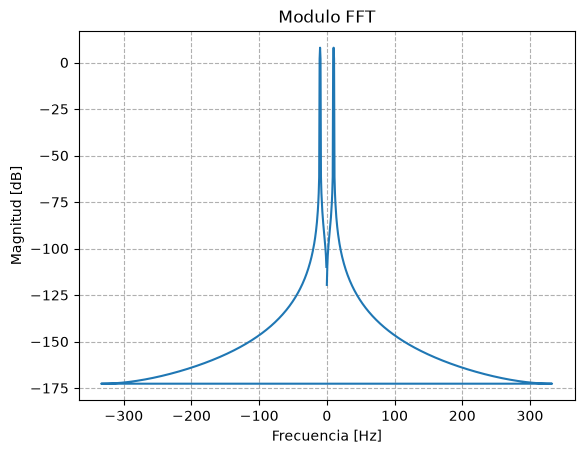

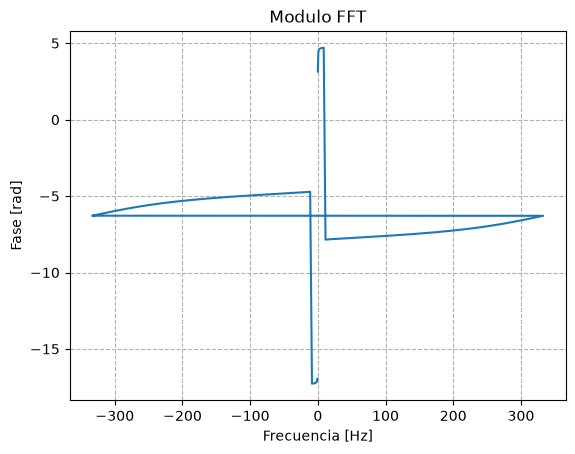

In [ ]:
import electro.dsp as dsp 
import electro.graphics.plot as plot
import numpy as np

import matplotlib.pyplot as plt


# Creación de la función
TiempoMax = 1.5
CantMuestras = 1000
fs = CantMuestras/TiempoMax

t, seno = dsp.sin(5, 0, ff=10, nn=CantMuestras, fs=fs)
plt.plot(t, seno)
plt.show()
# Obtención de la FFT
fft_seno = dsp.fft(seno, window='hann')
#fft_seno = dsp.positive_spectrum(fft_seno)

ff = dsp.fft_freq(CantMuestras, fs)
#ff = dsp.positive_spectrum(ff)

# Gráfico de la FFT
plot.plot_mag(ff, fft_seno, title='Modulo FFT')
plt.show()
plot.plot_phase(ff, fft_seno, title='Modulo FFT')
plt.show()

---
# **GRÁFICO DE TRANSFORMADA Z**

Se realiza el gráfico de magnitud de una función transferencia en el dominio de Z.
útil para trabajar funciones conocidas discretas que no sean muestras tomadas (como en fft).

In [ ]:
from circuitanalysis import graphic as graph
from circuitanalysis import symbolic as sym

num = [0,4,8]
den = [4,4,1]
H = sym.TransferFunction(num, den)

H_z = sym.to_symbolic_transfer(H, sym.Z)		# Para verlo de forma simbolica
sym.print_latex(H_z)

_ = graph.ZbodeMagnitude(H)